# Step 1: Setup and a first run

Does the whole chain work: a Julia script runs an Oceananigans simulation, writes a NetCDF file outside the repository, and Python reads it and makes a plot? I ran a tiny, short lock exchange (32 x 5 cells, 2 model hours) with `simulations/run_step1.jl` and look at it here.

I load the libraries and set the paths and constants. The raw output lives in `~/oceananigans_runs/numerical_mixing/`, outside the git repository; this notebook only reads it.

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

RUNS = os.path.expanduser("~/oceananigans_runs/numerical_mixing")   # raw model output (outside the repo)
RUN = os.path.join(RUNS, "step1_tiny")                                # the step 1 test run
DELTA_B = 9.81 * 5.0 / 1000.0          # buoyancy difference between the water masses (m/s^2), g * 5 kg/m^3 / 1000 kg/m^3
FIG_DIR = "../figures"

The run wrote a small text file with its settings and outcome. It confirms the Oceananigans and Julia versions, the grid, the schemes, and that the tracer diffusivity is zero.

In [2]:
print(open(os.path.join(RUN, "run_info.txt")).read())

name = step1_tiny
status = completed
oceananigans_version = 0.113.5
julia_version = 1.13.1
Nx = 32
Nz = 5
dx_m = 2000.0
dz_m = 4.0
tracer_advection = WENO(order=5)
momentum_advection = WENO(order=5)
nu_h_m2_s = 0.01
nu_z_m2_s = 0.0001
tracer_diffusivity_m2_s = 0
time_stepping = adaptive, cfl = 0.20
stop_time_s = 7200.0
model_time_s = 7200.0
iterations = 444
wall_time_s = 20.58
delta_b_m_s2 = 0.04905



I open the NetCDF file with xarray. The dimension names show Oceananigans' staggered grid: buoyancy b sits at cell centres (`x_caa`, `z_aac`), the horizontal velocity u on the cell faces in x (`x_faa`), and the vertical velocity w on the faces in z (`z_aaf`). There is one snapshot every 10 minutes.

In [3]:
ds = xr.open_dataset(os.path.join(RUN, "fields.nc"))
print(ds[["b", "u", "w"]])
print(f"\n{ds.sizes['time']} snapshots from {float(ds.time[0]) / 3600:.1f} to {float(ds.time[-1]) / 3600:.1f} hours; "
      f"b is stored as {ds['b'].dtype}")

<xarray.Dataset> Size: 54kB
Dimensions:  (time: 13, z_aac: 5, x_caa: 32, x_faa: 33, z_aaf: 6)
Coordinates:
  * time     (time) float64 104B 0.0 600.0 1.2e+03 ... 6e+03 6.6e+03 7.2e+03
  * z_aac    (z_aac) float64 40B -18.0 -14.0 -10.0 -6.0 -2.0
  * x_caa    (x_caa) float64 256B 1e+03 3e+03 5e+03 ... 5.9e+04 6.1e+04 6.3e+04
  * x_faa    (x_faa) float64 264B 0.0 2e+03 4e+03 ... 6e+04 6.2e+04 6.4e+04
  * z_aaf    (z_aaf) float64 48B -20.0 -16.0 -12.0 -8.0 -4.0 0.0
Data variables:
    b        (time, z_aac, x_caa) float64 17kB ...
    u        (time, z_aac, x_faa) float64 17kB ...
    w        (time, z_aaf, x_caa) float64 20kB ...
Attributes:
    Julia:                 This file was generated using 
    Oceananigans:          This file was generated using Oceananigans v0.113.5
    date:                  This file was generated on 2026-10-06T11:47:02.664...
    interval:              600.0
    output time interval:  Output was saved every 10 minutes.
    schedule:              TimeInterval


The first plot: buoyancy at the start and after 2 hours. At t = 0 the dense water (b = 0) fills the left half and the light water (b = 0.049 m/s^2) the right half. After 2 hours the dense water should be sliding under the light water to the right, and the light water over it to the left.

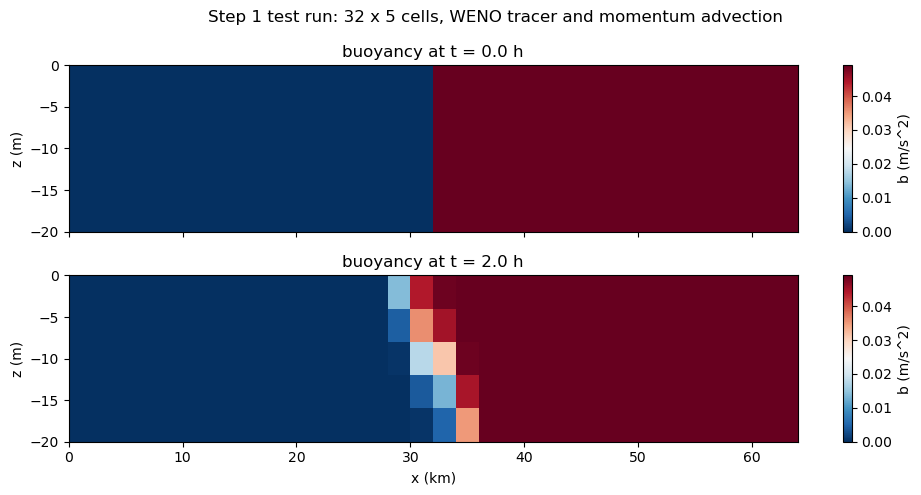

In [4]:
x_km = ds.x_caa / 1e3
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, t_index in zip(axes, [0, -1]):
    snapshot = ds["b"].isel(time=t_index)
    mesh = ax.pcolormesh(x_km, ds.z_aac, snapshot, cmap="RdBu_r", vmin=0, vmax=DELTA_B, shading="nearest")
    ax.set_ylabel("z (m)")
    ax.set_title(f"buoyancy at t = {float(ds.time[t_index]) / 3600:.1f} h")
    fig.colorbar(mesh, ax=ax, label="b (m/s^2)")
axes[-1].set_xlabel("x (km)")
fig.suptitle("Step 1 test run: 32 x 5 cells, WENO tracer and momentum advection")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "01_first_run_buoyancy.png"), dpi=150)
plt.show()

The run also wrote `log.csv` every 10 iterations, with the time step and simple statistics. Two quick checks: the total buoyancy (sum of b times cell area) should stay constant, because nothing enters or leaves the box; and b should stay between 0 and 0.049 m/s^2, because zero diffusivity means no new values should appear.

In [5]:
log = pd.read_csv(os.path.join(RUN, "log.csv"))
total = log["b_total_m3_per_s2"]
print(f"{len(log)} log lines, {int(log['iteration'].iloc[-1])} iterations, time step from {log['dt_s'].iloc[0]:.2f} s "
      f"to {log['dt_s'].iloc[-1]:.2f} s")
print(f"total buoyancy: start {total.iloc[0]:.6f}, end {total.iloc[-1]:.6f}, "
      f"largest relative change {np.max(np.abs(total - total.iloc[0])) / total.iloc[0]:.2e}")
print(f"b range over the run: {log['b_min'].min():.3e} to {log['b_max'].max():.6e} m/s^2 "
      f"(start: 0 to {DELTA_B:.6e}); undershoot {-log['b_min'].min() / DELTA_B:.1e} of the difference, "
      f"overshoot {(log['b_max'].max() - DELTA_B) / DELTA_B:.1e}")
print(f"largest speed {log['u_max_abs'].max():.3f} m/s; largest advective CFL number {log['advective_cfl'].max():.3f}")

45 log lines, 440 iterations, time step from 1.10 s to 72.89 s
total buoyancy: start 31392.000000, end 31391.999587, largest relative change 2.09e-08
b range over the run: -7.074e-07 to 4.905071e-02 m/s^2 (start: 0 to 4.905000e-02); undershoot 1.4e-05 of the difference, overshoot 1.4e-05
largest speed 0.643 m/s; largest advective CFL number 0.045
